# Spatial Axis Comparison: RT Encoding vs. Waveform Features vs. MERFISH vs. Retrograde Tracing

This notebook asks: **Does the spatial gradient of RT encoding within LC align with 
the waveform-type, transcriptomic, and/or projection-target organization axes?**

Adapted from Han Yu's `F_spatial-axis-comparison.ipynb` (aind-beh-ephys-analysis).

## Strategy
1. Load your `combined_unit_tbl.pkl` and filter units (same pipeline as `tongue_kinematics_ephys.ipynb`)
2. Compute per-unit RT encoding stats via OLS (spike_count ~ log(RT)) using `build_sue_plus_with_rt_models` or the `PerUnitStatsRegistry`
3. Extract CCF coordinates → bregma-centered LPS mm
4. Fit a **spatial axis** to RT encoding t-stats using `fit_spatial_axis_linear` (scalar → OLS) or `fit_spatial_axis_cca` (multivariate → CCA)
5. Bootstrap the axis direction (2000 resamples) → 95% confidence cone
6. Load Han's waveform, MERFISH, and retrograde axes (or recompute from capsule data)
7. Compare axes with `compare_bootstrap_directions` → angle + Wald test p-value


In [61]:
pip install scanpy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [62]:
# --- Standard Library ---
import os
import re
import pickle
from pathlib import Path
from typing import Optional, Tuple, Dict
from dataclasses import dataclass

# --- Third-Party ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import seaborn as sns
from scipy.stats import chi2
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.cross_decomposition import CCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from trimesh import load_mesh

# --- Local ---
# Adjust these imports to match your capsule's module structure
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_analysis import (
    get_session_name_from_path,
    session_already_done,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    get_session_prefix,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_analysis import (
    get_session_name_from_path,
    session_already_done,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    annotate_movement_timing,
    add_lick_metadata_to_movements,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    get_events_dict,
    build_event_df,
    RasterPlotter,
    find_session_dir,
    load_intermediate_data,
    get_session_prefix,
)
from ccf_utils import pir_to_lps, project_to_plane

import scanpy as sc

%matplotlib inline


## 1. Load and filter ephys units
Same data loading pipeline as `tongue_kinematics_ephys.ipynb` cells 2–4.


In [63]:
# --- Load combined unit table ---
with open('/root/capsule/scratch/combined_unit_tbl.pkl', 'rb') as file:
    combined_ephys_data = pickle.load(file)

# --- Session quality filter (tongue tracking) ---
base_dirs = [Path("/root/capsule/scratch/session_analysis_mlk")]

COVERAGE_MIN = 90.0
DURATION50_MIN = 0.06

rows_pass = []
for base_dir in base_dirs:
    if not base_dir.exists():
        continue
    for subdir in base_dir.iterdir():
        if not (subdir.is_dir() and session_already_done(subdir)):
            continue
        json_file = subdir / "tongue_quality_stats.json"
        try:
            import json as _json
            with open(json_file, "r") as f:
                d = _json.load(f)
        except Exception:
            continue
        cov = float(d.get("coverage_pct", 0.0))
        dur50 = float(d.get("percentiles", {}).get("duration", {}).get("0.5", 0.0))
        if cov > COVERAGE_MIN and dur50 > DURATION50_MIN:
            rows_pass.append({"session_path": subdir, "session_id": d.get("session_id", subdir.name)})

filtered_session_paths = [r["session_path"] for r in rows_pass]
session_order_full = [get_session_name_from_path(str(p)) for p in filtered_session_paths]
session_prefix_order = [get_session_prefix(s) for s in session_order_full]
session_prefix_allow = set(session_prefix_order)

print(f"Sessions passing tongue QC: {len(filtered_session_paths)}")


Sessions passing tongue QC: 44


In [64]:
DEFAULT_CRITERIA = {
    "isi_violations": {"bounds": [0.0, 0.1]},
    "p_max":         {"bounds": [0.5, 1.0]},
    "lat_max_p":     {"bounds": [0.005, 0.02]},
    "eu":            {"bounds": [0.0, 0.25]},
    "corr":          {"bounds": [0.95, 1.0]},
    "qc_pass":       {"items":  [True]},
    "peak":          {"bounds": [-1000, 0]},
    "trial_count":   {"bounds": [100, 2000]},
    "in_df":         {"items":  [True]},
}

def filter_by_criteria(df, criteria=None):
    if criteria is None:
        criteria = DEFAULT_CRITERIA
    mask = pd.Series(True, index=df.index)
    for col, rule in criteria.items():
        if "bounds" in rule:
            lo, hi = rule["bounds"]
            mask &= df[col].between(lo, hi, inclusive="both")
        if "items" in rule:
            mask &= df[col].isin(rule["items"])
    return df.loc[mask].copy()

combined_ephys_data = combined_ephys_data.copy()
combined_ephys_data["session_prefix"] = combined_ephys_data["session"].map(get_session_prefix)

criteria_filtered = filter_by_criteria(combined_ephys_data, DEFAULT_CRITERIA)
filtered_ephys = criteria_filtered.loc[
    criteria_filtered["session_prefix"].isin(session_prefix_allow)
].copy()

print(f"Units after QC + session filter: {len(filtered_ephys)}")
print(f"Sessions represented: {filtered_ephys['session_prefix'].nunique()}")


Units after QC + session filter: 104
Sessions represented: 32


In [65]:
ROOT_SCRATCH = "/root/capsule/data/LC-NE_scratch_data_1"

def get_animal_id(session):
    m = re.match(r'^behavior_(\d+)_', session)
    if not m:
        raise ValueError(f"Cannot parse animal id from session: {session}")
    return m.group(1)

def find_summary_pkl(root, session):
    animal = get_animal_id(session)
    exact = Path(root) / animal / session / "ephys" / "opto" / "curated" / f"{session}_curated_soma_opto_tagging_summary.pkl"
    if exact.exists():
        return exact
    pref = get_session_prefix(session)
    candidates = list((Path(root) / animal).glob(
        f"{pref}_*/ephys/opto/curated/*_curated_soma_opto_tagging_summary.pkl"
    ))
    return candidates[0] if candidates else None

units_with_spikes = []
for session, subdf in filtered_ephys.groupby("session"):
    pkl_path = find_summary_pkl(ROOT_SCRATCH, session)
    if pkl_path is None:
        print(f"[skip] No summary .pkl for {session}")
        continue
    with open(pkl_path, "rb") as f:
        ephys_session_data = pickle.load(f)
    if not isinstance(ephys_session_data, pd.DataFrame):
        try:
            ephys_session_data = pd.DataFrame(ephys_session_data)
        except Exception:
            continue
    unit_ids = subdf["unit"].unique()
    ephys_data = (
        ephys_session_data[ephys_session_data["unit_id"].isin(unit_ids)]
        .copy()
        .assign(session=session)
    )
    units_with_spikes.append(ephys_data)

units_with_spikes = (
    pd.concat(units_with_spikes, ignore_index=True)
    if units_with_spikes else pd.DataFrame(columns=["session", "unit_id", "spike_times"])
)
print(f"units_with_spikes: {units_with_spikes.shape}")


units_with_spikes: (103, 54)


## 2. Compute per-unit RT encoding statistics

We need `all_counts_df` (per-trial spike counts with RT) to run the OLS regression.
This reuses your `AnalysisConfig` / `make_session_bundle` / `analyze_unit_for_session` pipeline.


In [66]:
@dataclass
class AnalysisConfig:
    align_key: str = "goCue"
    count_window_s: Tuple[float, float] = (0.0, 0.100)
    min_trials_per_group: int = 8
    only_cue_response_trials: bool = True
    latency_window_s: Optional[Tuple[float, float]] = None
    baseline_window_s: Optional[Tuple[float, float]] = None


def count_spikes_in_window(spike_times_sorted, t0, window):
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return 0
    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")
    return int(i1 - i0)


def first_spike_latency_in_window(spike_times_sorted, t0, window):
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan, False
    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")
    if i0 < i1:
        return float(spike_times_sorted[i0] - t0), True
    return np.nan, False


def build_trial_features(movs, licks, df_trials):
    tm = movs.copy()
    required_cols = {
        "cue_response_movement_number",
        "movement_latency_from_go",
        "movement_number_in_trial",
        "cue_response",
    }
    missing = required_cols - set(tm.columns)
    if missing:
        raise ValueError(f"movs missing required columns {missing}")

    crmn = tm.groupby("trial")["cue_response_movement_number"].first().astype("Int64")
    rt_first = tm.groupby("trial")["movement_latency_from_go"].min()

    if "cue_response" in tm.columns:
        rt_cr = (
            tm.loc[tm["cue_response"] == True]
              .groupby("trial")["movement_latency_from_go"]
              .first()
        )
    else:
        rt_cr = pd.Series(dtype=float)

    out = pd.DataFrame({
        "cue_response_movement_number": crmn,
        "reaction_time_firstmove": rt_first,
        "reaction_time_cueresponse": rt_cr,
    })

    kcols = ["peak_velocity", "duration", "excursion_angle_deg", "endpoint_x", "endpoint_y",
             "out_duration", "out_peak_velocity", "out_mean_velocity", "out_total_distance"]

    first_moves = (
        tm.loc[tm["movement_number_in_trial"] == 1, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"first_move_{c}" for c in kcols})
    )
    cue_resp_moves = (
        tm.loc[tm["cue_response"] == True, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"cue_response_{c}" for c in kcols})
    )
    out = out.join(first_moves, how="left").join(cue_resp_moves, how="left").sort_index()
    return out


def make_session_bundle(session, cfg):
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)
    movs, trials, licks, kins, evnts = data["movs"], data["trials"], data["licks"], data["kins"], data["events"]
    session_offset = evnts[evnts['event'] == 'goCue_start_time']['raw_timestamps'].iloc[0]

    events_dict = get_events_dict(trials, licks, kins)
    E = build_event_df(events_dict)
    Ev = E.dropna(subset=[cfg.align_key])
    align_times = Ev[cfg.align_key].astype(float)
    trial_features = build_trial_features(movs, licks, trials)

    if cfg.only_cue_response_trials:
        cr_trials = trial_features.index[trial_features["cue_response_movement_number"].notna()]
        keep = align_times.index.intersection(cr_trials)
        align_times = align_times.loc[keep]
        trial_features = trial_features.loc[keep]

    return {
        "session": session,
        "align_times": align_times,
        "trial_features": trial_features,
        "session_offset": session_offset,
    }


def analyze_unit_for_session(unit_row, bundle, cfg):
    session = bundle["session"]
    unit_id = unit_row["unit_id"]
    spikes = np.asarray(unit_row["spike_times"], dtype=float) - bundle["session_offset"]

    t0_map = bundle["align_times"].to_dict()
    win_count = cfg.count_window_s
    win_base = cfg.baseline_window_s
    win_lat = cfg.latency_window_s if cfg.latency_window_s is not None else cfg.count_window_s

    dur = win_count[1] - win_count[0]
    dur_b = win_base[1] - win_base[0] if win_base is not None else np.nan

    recs = []
    for tr in bundle["align_times"].index:
        t0 = t0_map.get(tr, np.nan)
        if not np.isfinite(t0):
            continue
        n = count_spikes_in_window(spikes, t0, win_count)
        n_base = count_spikes_in_window(spikes, t0, win_base) if win_base else np.nan
        fsl, had = first_spike_latency_in_window(spikes, t0, win_lat)
        recs.append({
            "unit_id": unit_id, "session": session, "trial": int(tr),
            "spike_count": int(n),
            "spike_rate_hz": (n / dur) if dur > 0 else np.nan,
            "baseline_spike_count": n_base,
            "baseline_spike_rate_hz": (n_base / dur_b) if dur_b > 0 else np.nan,
            "first_spike_latency_s": fsl,
        })
    unit_counts = pd.DataFrame(recs).set_index("trial")
    unit_counts = unit_counts.join(bundle["trial_features"], how="left").reset_index()
    return unit_counts

In [67]:
cfg = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.2),
    baseline_window_s=(-1, 0.0),
    min_trials_per_group=20,
)
bundle_cache: Dict[str, dict] = {}
all_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session
    if session not in bundle_cache:
        bundle_cache[session] = make_session_bundle(session, cfg)
    unit_counts = analyze_unit_for_session(
        pd.Series(u._asdict()), bundle_cache[session], cfg
    )
    all_counts.append(unit_counts)

all_counts_df = pd.concat(all_counts, ignore_index=True).sort_values(
    ["session", "unit_id", "trial"]
)
print("all_counts_df shape:", all_counts_df.shape)
print("Columns:", all_counts_df.columns.tolist())

all_counts_df shape: (31993, 29)
Columns: ['trial', 'unit_id', 'session', 'spike_count', 'spike_rate_hz', 'baseline_spike_count', 'baseline_spike_rate_hz', 'first_spike_latency_s', 'cue_response_movement_number', 'reaction_time_firstmove', 'reaction_time_cueresponse', 'first_move_peak_velocity', 'first_move_duration', 'first_move_excursion_angle_deg', 'first_move_endpoint_x', 'first_move_endpoint_y', 'first_move_out_duration', 'first_move_out_peak_velocity', 'first_move_out_mean_velocity', 'first_move_out_total_distance', 'cue_response_peak_velocity', 'cue_response_duration', 'cue_response_excursion_angle_deg', 'cue_response_endpoint_x', 'cue_response_endpoint_y', 'cue_response_out_duration', 'cue_response_out_peak_velocity', 'cue_response_out_mean_velocity', 'cue_response_out_total_distance']


In [68]:
# -------------------------------------------------------------------
# NOTE: This cell requires your make_session_bundle and 
# analyze_unit_for_session functions from tongue_kinematics_ephys.ipynb.
# Import or paste them here. They produce `all_counts_df` with columns:
#   session, unit_id, trial, spike_count, baseline_spike_count, 
#   reaction_time_firstmove, ...
# -------------------------------------------------------------------

# If you've already computed all_counts_df, just load it:
# all_counts_df = pd.read_parquet("/root/capsule/scratch/all_counts_df.parquet")

# Otherwise, run the spike-counting loop:
# from tongue_kinematics_ephys import AnalysisConfig, make_session_bundle, analyze_unit_for_session
# 
# cfg = AnalysisConfig(
#     align_key="goCue",
#     count_window_s=(0.0, 0.2),
#     baseline_window_s=(-1, 0.0),
#     min_trials_per_group=20,
# )
# bundle_cache = {}
# all_counts = []
# for u in units_with_spikes.itertuples(index=False):
#     session = u.session
#     if session not in bundle_cache:
#         bundle_cache[session] = make_session_bundle(session, cfg)
#     unit_counts = analyze_unit_for_session(pd.Series(u._asdict()), bundle_cache[session], cfg)
#     all_counts.append(unit_counts)
# all_counts_df = pd.concat(all_counts, ignore_index=True)

print("all_counts_df shape:", all_counts_df.shape)
print("columns:", list(all_counts_df.columns))


all_counts_df shape: (31993, 29)
columns: ['trial', 'unit_id', 'session', 'spike_count', 'spike_rate_hz', 'baseline_spike_count', 'baseline_spike_rate_hz', 'first_spike_latency_s', 'cue_response_movement_number', 'reaction_time_firstmove', 'reaction_time_cueresponse', 'first_move_peak_velocity', 'first_move_duration', 'first_move_excursion_angle_deg', 'first_move_endpoint_x', 'first_move_endpoint_y', 'first_move_out_duration', 'first_move_out_peak_velocity', 'first_move_out_mean_velocity', 'first_move_out_total_distance', 'cue_response_peak_velocity', 'cue_response_duration', 'cue_response_excursion_angle_deg', 'cue_response_endpoint_x', 'cue_response_endpoint_y', 'cue_response_out_duration', 'cue_response_out_peak_velocity', 'cue_response_out_mean_velocity', 'cue_response_out_total_distance']


In [69]:
def build_rt_encoding_stats(
    all_counts_df,
    *,
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    baseline_col="baseline_spike_count",
    session_col="session",
    unit_col="unit_id",
    min_trials=50,
    log_rt=True,
    zscore_rt=True,
    alpha=0.05,
):
    """
    OLS regression: spike_count ~ 1 + log(RT)  (and baseline ~ 1 + log(RT))
    Returns DataFrame with per-(session_prefix, unit) t-stats, p-values, coefficients.
    """
    def canon_unit(x):
        try:
            return str(int(float(x)))
        except Exception:
            return str(x)

    counts = all_counts_df.copy()
    counts[session_col] = counts[session_col].astype(str)
    counts[unit_col] = counts[unit_col].map(canon_unit)
    counts["session_prefix"] = counts[session_col].map(get_session_prefix)
    counts["unit"] = counts[unit_col]

    def _fit_one_model(g, y_col, suffix):
        g = g.dropna(subset=[rt_col, y_col])
        rt = g[rt_col].to_numpy(dtype=float)
        y = g[y_col].to_numpy(dtype=float)

        if log_rt:
            m = np.isfinite(rt) & (rt > 0) & np.isfinite(y)
            rt, y = rt[m], y[m]
        else:
            m = np.isfinite(rt) & np.isfinite(y)
            rt, y = rt[m], y[m]

        n = int(rt.size)
        nans = {f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan, "n_trials": n}

        if n < min_trials or np.nanstd(rt) == 0 or np.nanstd(y) == 0:
            return nans

        x = np.log(rt) if log_rt else rt
        if zscore_rt:
            x = (x - np.nanmean(x)) / np.nanstd(x)

        X = sm.add_constant(x)
        try:
            res = sm.OLS(y, X).fit()
            return {
                f"coef_{suffix}": float(res.params[1]),
                f"T_{suffix}": float(res.tvalues[1]),
                f"p_{suffix}": float(res.pvalues[1]),
                "n_trials": n,
            }
        except Exception:
            return nans

    rows = []
    for (sp, u), g in counts.groupby(["session_prefix", "unit"]):
        result = {"session_prefix": sp, "unit": u}
        result.update(_fit_one_model(g, count_col, "rt"))
        result.update(_fit_one_model(g, baseline_col, "rt_bl"))
        rows.append(result)

    out = pd.DataFrame(rows)

    # FDR correction
    for suffix in ["rt", "rt_bl"]:
        pcol = f"p_{suffix}"
        qcol = f"q_{suffix}"
        out[qcol] = np.nan
        m = out[pcol].notna()
        if m.any():
            _, q, _, _ = multipletests(out.loc[m, pcol].values, alpha=alpha, method="fdr_bh")
            out.loc[m, qcol] = q

    return out

rt_stats = build_rt_encoding_stats(all_counts_df)
print(f"RT encoding stats computed for {len(rt_stats)} units")
print(f"  Response: {(rt_stats['p_rt'] < 0.05).sum()} nominally sig, "
      f"{(rt_stats['q_rt'].fillna(1) < 0.05).sum()} FDR sig")
print(f"  Baseline: {(rt_stats['p_rt_bl'] < 0.05).sum()} nominally sig, "
      f"{(rt_stats['q_rt_bl'].fillna(1) < 0.05).sum()} FDR sig")


RT encoding stats computed for 103 units
  Response: 42 nominally sig, 36 FDR sig
  Baseline: 39 nominally sig, 27 FDR sig


## 3. Merge RT encoding with CCF coordinates

In [70]:
# Merge rt_stats onto filtered_ephys (which has x_ccf, y_ccf, z_ccf)
features_combined = filtered_ephys.copy()
features_combined["session_prefix"] = features_combined["session"].map(get_session_prefix)

def canon_unit(x):
    try:
        return str(int(float(x)))
    except Exception:
        return str(x)

features_combined["unit_str"] = features_combined["unit"].map(canon_unit)
rt_stats["unit_str"] = rt_stats["unit"].astype(str)

features_combined = features_combined.merge(
    rt_stats.rename(columns={"unit": "unit_rt"}),
    left_on=["session_prefix", "unit_str"],
    right_on=["session_prefix", "unit_str"],
    how="left",
)

n_with_rt = features_combined["T_rt"].notna().sum()
n_with_ccf = features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1).sum()
print(f"Units with RT encoding stats: {n_with_rt}")
print(f"Units with CCF coordinates: {n_with_ccf}")
print(f"Units with both: {(features_combined['T_rt'].notna() & features_combined[['x_ccf','y_ccf','z_ccf']].notna().all(axis=1)).sum()}")


Units with RT encoding stats: 103
Units with CCF coordinates: 101
Units with both: 100


## 4. CCF coordinate setup & LC mesh

In [71]:
# ---- CCF constants ----
ml, ap, dv = 0, 1, 2
BREGMA_LPS_MM = np.array([-5.7, 5.4, -0.45], dtype=float)

PLANES = {
    "sag": [ap, dv],
    "hor": [ml, ap],
    "cor": [ml, dv],
}

def ccf_points_lps_mm(df, fold_left=True):
    """Nx3 LPS mm coords, bregma-centered, ML positive (Han's convention)."""
    ccfs = df[["x_ccf", "y_ccf", "z_ccf"]].to_numpy(dtype=float)
    ccfs = ccfs - BREGMA_LPS_MM
    if fold_left:
        ccfs[:, ml] = np.abs(ccfs[:, ml])   # POSITIVE, matching Han
    return ccfs

# ---- Load LC mesh (Han's mesh + Han's transform) ----
MESH_PATH = "/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj"

mesh = load_mesh(MESH_PATH)
mesh_vertices_mm = np.array(mesh.vertices, dtype=float) / 1000.0

# Han's transform for new_core_mesh (not the PIR pipeline):
mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]  # negate Z
mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]  # negate X
mesh_vertices_mm = mesh_vertices_mm - BREGMA_LPS_MM
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])  # positive ML

mesh_contours = {
    name: project_to_plane(mesh_vertices_mm, axes, pitch=0.02, margin=0.5)
    for name, axes in PLANES.items()
}

# Mesh centroid for projection centering (positive ML, matching Han)
mesh_centroid = np.mean(mesh_vertices_mm, axis=0)

print(f"Mesh loaded: {MESH_PATH}")
print(f"Mesh centroid (LPS mm): {mesh_centroid}")

Mesh loaded: /root/capsule/data/LC_percentile_meshes/new_core_mesh.obj
Mesh centroid (LPS mm): [ 0.90500577  5.11048914 -3.88417673]


## 5. Spatial axis fitting & bootstrap machinery

These functions are adapted from Han's `F_spatial-axis-comparison.ipynb`. 
Three fitting methods are provided depending on feature type:
- **Linear** (scalar feature → OLS) — use for RT encoding t-stats
- **CCA** (multivariate features → canonical correlation) — use for waveform features, gene expression
- **LDA** (categorical labels → discriminant axis) — use for retrograde tracing injection sites


In [72]:
# ============================================================
# Core: normalize to unit vector
# ============================================================
def _unit(v, eps=1e-15):
    v = np.asarray(v, dtype=float).reshape(-1)
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Cannot normalize a near-zero vector.")
    return v / n


# ============================================================
# Linear: scalar feature ~ 3D coords
# ============================================================
def fit_spatial_axis_linear(feature, coords, *, add_intercept=True):
    """
    OLS: feature ~ 1 + coords.  Returns unit-vector direction of beta.
    """
    y = np.asarray(feature, dtype=float).reshape(-1)
    X = np.asarray(coords, dtype=float)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y, X = y[ok], X[ok]
    if len(y) < 4:
        raise ValueError("Need >= 4 valid samples.")

    if add_intercept:
        X_design = np.column_stack([np.ones(len(X)), X])
        coef = np.linalg.lstsq(X_design, y, rcond=None)[0]
        beta = coef[1:]
    else:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]

    beta = np.asarray(beta, dtype=float).reshape(3)
    return {"axis_unit": _unit(beta), "beta": beta, "intercept": 0.0}


def bootstrap_spatial_axis_linear(
    feature, coords, *, n_boot=2000, seed=0, align_to_observed=True
):
    """Bootstrap the linear spatial axis direction."""
    y = np.asarray(feature, dtype=float).reshape(-1)
    X = np.asarray(coords, dtype=float)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y, X = y[ok], X[ok]
    n = len(y)

    obs = fit_spatial_axis_linear(y, X)
    axis_obs = obs["axis_unit"]
    rng = np.random.default_rng(seed)

    axis_boot = []
    failed = 0
    for _ in range(n_boot):
        ind = rng.integers(0, n, size=n)
        try:
            res_b = fit_spatial_axis_linear(y[ind], X[ind])
            axis_b = res_b["axis_unit"]
            if align_to_observed and np.dot(axis_b, axis_obs) < 0:
                axis_b = -axis_b
            axis_boot.append(axis_b)
        except Exception:
            failed += 1

    return {
        "axis_unit": axis_obs,
        "beta": obs["beta"],
        "axis_boot": np.array(axis_boot),
        "n_boot_valid": len(axis_boot),
        "n_boot_failed": failed,
    }


# ============================================================
# CCA: multivariate features ~ 3D coords
# ============================================================
def fit_spatial_axis_cca(features, coords, *, standardize_features=True):
    """CCA: find 3D direction maximally correlated with feature variation."""
    S = np.asarray(features, dtype=float)
    X = np.asarray(coords, dtype=float)
    if S.ndim == 1:
        S = S.reshape(-1, 1)
    ok = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(S), axis=1)
    X, S = X[ok], S[ok]
    if len(X) < 4:
        raise ValueError("Need >= 4 valid samples.")

    keep_feat = np.nanstd(S, axis=0) > 0
    S = S[:, keep_feat]
    if standardize_features:
        S = StandardScaler().fit_transform(S)

    max_comp = min(1, X.shape[1], S.shape[1], len(X) - 1)
    cca = CCA(n_components=max_comp)
    cca.fit(X, S)
    X_c, S_c = cca.transform(X, S)
    canonical_corr = float(np.corrcoef(X_c[:, 0], S_c[:, 0])[0, 1])

    beta = np.asarray(cca.x_weights_[:, 0], dtype=float).reshape(3)
    return {"axis_unit": _unit(beta), "beta": beta, "intercept": 0.0,
            "canonical_corr": canonical_corr}


def bootstrap_spatial_axis_cca(
    features, coords, *, n_boot=2000, seed=0, align_to_observed=True,
    standardize_features=True,
):
    """Bootstrap the CCA spatial axis."""
    S = np.asarray(features, dtype=float)
    X = np.asarray(coords, dtype=float)
    if S.ndim == 1:
        S = S.reshape(-1, 1)
    ok = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(S), axis=1)
    X, S = X[ok], S[ok]

    obs = fit_spatial_axis_cca(S, X, standardize_features=standardize_features)
    axis_obs = obs["axis_unit"]
    rng = np.random.default_rng(seed)
    n = len(X)

    axis_boot = []
    failed = 0
    for _ in range(n_boot):
        ind = rng.integers(0, n, size=n)
        try:
            res_b = fit_spatial_axis_cca(S[ind], X[ind], standardize_features=standardize_features)
            axis_b = res_b["axis_unit"]
            if align_to_observed and np.dot(axis_b, axis_obs) < 0:
                axis_b = -axis_b
            axis_boot.append(axis_b)
        except Exception:
            failed += 1

    return {
        "axis_unit": axis_obs, "beta": obs["beta"],
        "canonical_corr": obs["canonical_corr"],
        "axis_boot": np.array(axis_boot),
        "n_boot_valid": len(axis_boot), "n_boot_failed": failed,
    }


# ============================================================
# LDA: categorical labels ~ 3D coords
# ============================================================
def _pd_notnull_1d(arr):
    arr = np.asarray(arr, dtype=object)
    out = np.ones(len(arr), dtype=bool)
    for i, v in enumerate(arr):
        if v is None:
            out[i] = False
        else:
            try:
                if isinstance(v, float) and np.isnan(v):
                    out[i] = False
            except Exception:
                pass
    return out


def fit_spatial_axis_LDA(labels, coords):
    """LDA on 3D coords predicting categorical labels → first discriminant axis."""
    y = np.asarray(labels)
    X = np.asarray(coords, dtype=float)
    ok = np.all(np.isfinite(X), axis=1) & _pd_notnull_1d(y)
    y, X = y[ok], X[ok]

    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2 or np.any(counts < 2):
        raise ValueError("Need >= 2 classes with >= 2 samples each.")

    lda = LinearDiscriminantAnalysis(n_components=1)
    lda.fit(X, y)
    beta = np.asarray(lda.scalings_[:, 0], dtype=float).reshape(3)
    return {"axis_unit": _unit(beta), "beta": beta, "intercept": 0.0}


def bootstrap_spatial_axis_LDA(
    labels, coords, *, n_boot=2000, seed=0, align_to_observed=True
):
    """Bootstrap the LDA spatial axis."""
    y = np.asarray(labels)
    X = np.asarray(coords, dtype=float)
    ok = np.all(np.isfinite(X), axis=1) & _pd_notnull_1d(y)
    y, X = y[ok], X[ok]
    n = len(y)

    obs = fit_spatial_axis_LDA(y, X)
    axis_obs = obs["axis_unit"]
    rng = np.random.default_rng(seed)

    axis_boot = []
    failed = 0
    for _ in range(n_boot):
        ind = rng.integers(0, n, size=n)
        yb, Xb = y[ind], X[ind]
        classes_b, counts_b = np.unique(yb, return_counts=True)
        if len(classes_b) < 2 or np.any(counts_b < 2):
            failed += 1
            continue
        try:
            res_b = fit_spatial_axis_LDA(yb, Xb)
            axis_b = res_b["axis_unit"]
            if align_to_observed and np.dot(axis_b, axis_obs) < 0:
                axis_b = -axis_b
            axis_boot.append(axis_b)
        except Exception:
            failed += 1

    return {
        "axis_unit": axis_obs, "beta": obs["beta"],
        "axis_boot": np.array(axis_boot),
        "n_boot_valid": len(axis_boot), "n_boot_failed": failed,
    }


In [73]:
# ============================================================
# Direction comparison (bootstrap Wald test)
# ============================================================
def _orthonormal_basis_perp(v0, v1):
    u0 = _unit(v0)
    diff = v1 - np.dot(v1, u0) * u0
    if np.linalg.norm(diff) < 1e-12:
        a = np.array([1., 0., 0.]) if abs(u0[0]) < 0.9 else np.array([0., 1., 0.])
        diff = a - np.dot(a, u0) * u0
    e1 = _unit(diff)
    e2 = _unit(np.cross(u0, e1))
    return e1, e2, u0


def compare_bootstrap_directions(b_x, b_y, b_x_boot, b_y_boot):
    """
    Test whether two 3D unit-vector directions are significantly different.
    
    Returns dict with:
      - angle_deg: observed angle between axes
      - p_chi2: Wald test p-value (chi2, df=2)
      - p_boot: bootstrap permutation p-value
      - d_obs, d_boot: 2D tangent-plane projections
    """
    b_x, b_y = _unit(b_x), _unit(b_y)
    b_x_boot = np.asarray(b_x_boot, float)
    b_y_boot = np.asarray(b_y_boot, float)

    # Hemisphere-align
    flip_x = np.sum(b_x_boot * b_x[None, :], axis=1) < 0
    flip_y = np.sum(b_y_boot * b_y[None, :], axis=1) < 0
    b_x_boot[flip_x] *= -1
    b_y_boot[flip_y] *= -1

    # Normalize
    b_x_boot = b_x_boot / np.linalg.norm(b_x_boot, axis=1, keepdims=True)
    b_y_boot = b_y_boot / np.linalg.norm(b_y_boot, axis=1, keepdims=True)

    # Tangent plane at b_x, e1 aligned toward b_y
    e1, e2, u0 = _orthonormal_basis_perp(b_x, b_y)
    A = np.vstack([e1, e2])  # 2x3

    d_obs = A @ b_y
    Px = (A @ b_x_boot.T).T
    Py = (A @ b_y_boot.T).T

    n_boot = min(len(Px), len(Py))
    d_boot = Py[:n_boot] - Px[:n_boot]
    mean_boot = d_boot.mean(axis=0)

    cov_2d = np.cov(d_boot.T, ddof=1) + np.eye(2) * 1e-12
    cov_inv = np.linalg.inv(cov_2d)

    W_obs = float(d_obs.T @ cov_inv @ d_obs)
    p_chi2 = chi2.sf(W_obs, df=2)

    # Bootstrap p-value
    d_boot_null = d_boot - mean_boot[None, :]
    W_boot_null = np.einsum("ni,ij,nj->n", d_boot_null, cov_inv, d_boot_null)
    p_boot = (np.sum(W_boot_null >= W_obs) + 1) / (len(W_boot_null) + 1)

    cos_angle = np.clip(np.dot(b_x, b_y), -1, 1)
    angle_deg = np.degrees(np.arccos(cos_angle))

    return {
        "angle_deg": angle_deg,
        "p_chi2": p_chi2,
        "p_boot": p_boot,
        "W_obs": W_obs,
        "d_obs": d_obs,
        "d_boot": d_boot,
        "mean_boot": mean_boot,
        "cov_2d": cov_2d,
    }


# ============================================================
# Visualization helpers
# ============================================================
def vectors_to_az_el(vectors, degrees=True):
    v = np.asarray(vectors)
    az = np.arctan2(v[:, 1], v[:, 0])
    el = np.arcsin(np.clip(v[:, 2], -1, 1))
    if degrees:
        az, el = np.degrees(az), np.degrees(el)
    return az, el


def cone_half_angle(axis, axis_boot, q=95):
    axis = _unit(axis)
    angles = np.array([
        np.degrees(np.arccos(np.clip(np.dot(_unit(b), axis), -1, 1)))
        for b in axis_boot
    ])
    return np.percentile(angles, q), angles


def plot_projected_arrow_with_cone(
    ax, origin, axis, axis_boot, dims, *,
    color="red", scale=0.8, head_width=0.08, head_length=0.12,
    cone_q=95, cone_alpha=0.18, label=None,
):
    """Plot one projected arrow and its projected 95% cone on a 2D plane."""
    axis = _unit(axis)
    v2 = axis[list(dims)] * scale

    half_angle_deg, _ = cone_half_angle(axis, axis_boot, q=cone_q)

    # Cone boundary on unit sphere
    e1_3d = np.zeros(3)
    if abs(axis[0]) < 0.9:
        e1_3d[0] = 1.0
    else:
        e1_3d[1] = 1.0
    e1_3d = e1_3d - np.dot(e1_3d, axis) * axis
    e1_3d = _unit(e1_3d)
    e2_3d = _unit(np.cross(axis, e1_3d))

    theta = np.linspace(0, 2 * np.pi, 240)
    alpha_rad = np.radians(half_angle_deg)
    cone_3d = (
        np.cos(alpha_rad) * axis[None, :]
        + np.sin(alpha_rad) * (
            np.cos(theta)[:, None] * e1_3d[None, :]
            + np.sin(theta)[:, None] * e2_3d[None, :]
        )
    )
    cone_2d = cone_3d[:, list(dims)] * scale + origin[None, :]

    poly = np.vstack([origin[None, :], cone_2d, origin[None, :]])
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=cone_alpha, linewidth=0)
    ax.plot(cone_2d[:, 0], cone_2d[:, 1], color=color, alpha=0.6, linewidth=1)

    ax.arrow(origin[0], origin[1], v2[0], v2[1],
             head_width=head_width, head_length=head_length,
             fc=color, ec=color, linewidth=2, length_includes_head=True, label=label)

    return {"half_angle_deg": half_angle_deg}


## 6. Fit the RT encoding spatial axis

For your RT encoding t-stats (a scalar per unit), the **linear** method is appropriate:
regress `T_rt` onto `(ML, AP, DV)` coordinates to find the 3D direction along which
RT encoding strength varies most.


In [74]:
# ---- Prepare data ----
mask = (
    features_combined["T_rt"].notna()
    & features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)
)
fc = features_combined.loc[mask].copy()

coords_rt = ccf_points_lps_mm(fc, fold_left=True)
feature_rt = fc["T_rt"].to_numpy(dtype=float)

print(f"Fitting spatial axis for RT encoding: n = {len(feature_rt)} units")

# ---- Fit + bootstrap (linear: scalar feature) ----
n_boot = 2000

res_rt = bootstrap_spatial_axis_linear(
    feature_rt, coords_rt,
    n_boot=n_boot, seed=42, align_to_observed=True,
)

axis_rt = res_rt["axis_unit"]
axis_boot_rt = res_rt["axis_boot"]

half_angle, _ = cone_half_angle(axis_rt, axis_boot_rt, q=95)
print(f"RT encoding spatial axis: {axis_rt}")
print(f"  beta (raw): {res_rt['beta']}")
print(f"  95% cone half-angle: {half_angle:.1f}°")
print(f"  Bootstrap: {res_rt['n_boot_valid']} valid / {res_rt['n_boot_failed']} failed")


Fitting spatial axis for RT encoding: n = 100 units


RT encoding spatial axis: [0.81700376 0.5694651  0.09063311]
  beta (raw): [3.91497906 2.72880501 0.43430245]
  95% cone half-angle: 77.6°
  Bootstrap: 2000 valid / 0 failed


In [75]:
# ---- Optional: baseline RT encoding axis ----
mask_bl = (
    features_combined["T_rt_bl"].notna()
    & features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)
)
fc_bl = features_combined.loc[mask_bl].copy()
coords_bl = ccf_points_lps_mm(fc_bl, fold_left=True)
feature_bl = fc_bl["T_rt_bl"].to_numpy(dtype=float)

res_bl = bootstrap_spatial_axis_linear(
    feature_bl, coords_bl,
    n_boot=n_boot, seed=43, align_to_observed=True,
)
axis_bl = res_bl["axis_unit"]
axis_boot_bl = res_bl["axis_boot"]

half_bl, _ = cone_half_angle(axis_bl, axis_boot_bl, q=95)
print(f"Baseline RT encoding spatial axis: {axis_bl}")
print(f"  95% cone half-angle: {half_bl:.1f}°")


Baseline RT encoding spatial axis: [-0.94563228  0.18852679 -0.26502311]
  95% cone half-angle: 32.2°


## 7. Load comparison axes from Han's capsule

You need three datasets from the `aind-beh-ephys-analysis` capsule data:
1. **Waveform features** + unit CCF locations (from `combined_unit_tbl.pkl` + `combined_features.csv`)
2. **MERFISH** spatial transcriptomics (from `merfish_data/`)
3. **Retrograde tracing** (from `LC_retro/`)

If these data are mounted in your capsule, the cells below will load and fit them.
If not, you can load pre-computed axes from Han's results or skip to the comparison
using only your RT axes.


In [76]:
# ============================================================
# 7a. Waveform features (CCA)
# ============================================================
# Adjust paths to your capsule's data mount
CAPSULE_DATA = "/root/capsule/data"
FIG_PREP_DIR = os.path.join(CAPSULE_DATA, "LC-NE_scratch_data_1/combined")

# Load Han's combined_unit_tbl (for CCF) + waveform features
try:
    wf_tbl_path = os.path.join(FIG_PREP_DIR, "combine_unit_tbl", "combined_unit_tbl.pkl")
    with open(wf_tbl_path, "rb") as f:
        han_units = pickle.load(f)

    wf_feat_path = os.path.join("/root/capsule/data/results-59472bbb-4c3a-40f9-a1f5-b0c5113e4ab9-waveforms_np/", "combined_features.csv")
    wf_feats = pd.read_csv(wf_feat_path)
    
    # merge CCF onto waveform features
    wf_feats = wf_feats.merge(
        han_units[["session", "unit", "x_ccf", "y_ccf", "z_ccf"]],
        on=["session", "unit"], how="left"
    )
    
    wf_feature_cols = [
        "post_w", "trough_post_ratio_1D", "post_trough_slope",
        "pre_slope", "symmetry_slope_div_log",
        "symmetry_trough_dis", "symmetry_inte_div_log",
    ]
    
    ccf_wf = wf_feats[["x_ccf", "y_ccf", "z_ccf"]].values - BREGMA_LPS_MM
    ccf_wf[:, ml] = np.abs(ccf_wf[:, ml])
    
    valid_wf = ~np.any(np.isnan(ccf_wf), axis=1) & ~np.any(
        np.isnan(wf_feats[wf_feature_cols].values), axis=1
    )
    
    features_wf = wf_feats[wf_feature_cols].values[valid_wf]
    coords_wf = ccf_wf[valid_wf]
    
    res_wf = bootstrap_spatial_axis_cca(
        features_wf, coords_wf,
        n_boot=n_boot, seed=16, align_to_observed=True,
    )
    axis_wf = res_wf["axis_unit"]
    axis_boot_wf = res_wf["axis_boot"]
    
    ha_wf, _ = cone_half_angle(axis_wf, axis_boot_wf)
    print(f"Waveform axis: {axis_wf}, cone={ha_wf:.1f}°, n={len(coords_wf)}")
    HAS_WAVEFORM = True

except Exception as e:
    print(f"Could not load waveform data: {e}")
    print("Skipping waveform axis. You can set HAS_WAVEFORM=True after loading.")
    HAS_WAVEFORM = False


Waveform axis: [0.02763684 0.28186499 0.95905596], cone=47.6°, n=226


In [77]:
# ============================================================
# 7b. MERFISH spatial transcriptomics (CCA)
# ============================================================
try:
    import scanpy as sc
    
    merfish_path = os.path.join(CAPSULE_DATA, "merfish_data", "adata", "adata_mer_subset_2_2k.h5ad")
    adata_mer = sc.read_h5ad(merfish_path)
    
    # Normalize
    librarysize = np.sum(adata_mer.X, 1)
    adata_mer.X = 1000 * adata_mer.X / librarysize[:, None]
    
    # Remove ventral cells
    y_coord = adata_mer.obsm["spatial"][:, 1]
    keep = y_coord <= 220
    adata_mer = adata_mer[keep].copy()
    
    features_mer = adata_mer.X
    coord_mer = adata_mer.obsm["spatial"]
    
    # Convert to LPS mm
    from ccf_utils import ccf_pts_convert_to_mm
    coord_mer_mm = ccf_pts_convert_to_mm(coord_mer)
    coord_mer_mm = pir_to_lps(coord_mer_mm)
    coord_mer_mm[:, ml] = np.abs(coord_mer_mm[:, ml])
    coord_mer_mm[:, ap] = -coord_mer_mm[:, ap]
    
    valid_mer = coord_mer_mm[:, dv] > -10
    features_mer = features_mer[valid_mer]
    coord_mer_mm = coord_mer_mm[valid_mer]
    
    res_mer = bootstrap_spatial_axis_cca(
        features_mer, coord_mer_mm,
        n_boot=n_boot, seed=2, align_to_observed=True,
    )
    axis_mer = res_mer["axis_unit"]
    axis_boot_mer = res_mer["axis_boot"]
    
    ha_mer, _ = cone_half_angle(axis_mer, axis_boot_mer)
    print(f"MERFISH axis: {axis_mer}, cone={ha_mer:.1f}°, n={len(coord_mer_mm)}")
    HAS_MERFISH = True

except Exception as e:
    print(f"Could not load MERFISH data: {e}")
    HAS_MERFISH = False


MERFISH axis: [-0.24100181  0.49669996  0.83379091], cone=8.2°, n=2221


In [78]:
# ============================================================
# 7c. Retrograde tracing (LDA)
# ============================================================
try:
    retro_path = os.path.join(CAPSULE_DATA, "LC_retro", "manual_proofread_ccf_18brains.csv")
    retro_ccf = pd.read_csv(retro_path)
    
    bregma_pixel_retro = np.array([228, 18, 216])
    ccf_retro = (retro_ccf[["x", "y", "z"]].values - bregma_pixel_retro) * 25 / 1000
    ccf_retro[:, [dv, ap]] = ccf_retro[:, [ap, dv]]
    ccf_retro[:, dv] = -ccf_retro[:, dv]
    ccf_retro[:, ml] = np.abs(ccf_retro[:, ml])
    
    valid_retro = (retro_ccf["injection_region"].values != "TH") & (ccf_retro[:, dv] > -5)
    feature_retro = retro_ccf["injection_region"].values[valid_retro]
    coord_retro = ccf_retro[valid_retro]
    
    res_retro = bootstrap_spatial_axis_LDA(
        feature_retro, coord_retro,
        n_boot=n_boot, seed=0, align_to_observed=True,
    )
    
    # Align LDA axis sign with waveform axis if available
    if HAS_WAVEFORM and np.dot(res_retro["axis_unit"], axis_wf) < 0:
        res_retro["axis_unit"] = -res_retro["axis_unit"]
        res_retro["axis_boot"] = -res_retro["axis_boot"]
    
    axis_retro = res_retro["axis_unit"]
    axis_boot_retro = res_retro["axis_boot"]
    
    ha_retro, _ = cone_half_angle(axis_retro, axis_boot_retro)
    print(f"Retrograde axis: {axis_retro}, cone={ha_retro:.1f}°, n={len(coord_retro)}")
    HAS_RETRO = True

except Exception as e:
    print(f"Could not load retrograde data: {e}")
    HAS_RETRO = False


Retrograde axis: [0.06710185 0.29909511 0.95186105], cone=4.1°, n=9046


## 8. Compare axes: RT encoding vs. structural organization

The key question: **Does the spatial gradient of RT encoding align with 
the waveform / transcriptomic / projection-target gradients?**


In [79]:
# ---- Build list of axes to compare ----
axes_dict = {
    "RT encoding": (axis_rt, axis_boot_rt),
    "RT baseline": (axis_bl, axis_boot_bl),
}

if HAS_WAVEFORM:
    axes_dict["Waveform (CCA)"] = (axis_wf, axis_boot_wf)
if HAS_MERFISH:
    axes_dict["MERFISH (CCA)"] = (axis_mer, axis_boot_mer)
if HAS_RETRO:
    axes_dict["Retrograde (LDA)"] = (axis_retro, axis_boot_retro)

# ---- Pairwise comparisons ----
from itertools import combinations

print("=" * 70)
print("PAIRWISE SPATIAL AXIS COMPARISONS")
print("=" * 70)

comparison_results = {}
for (name_a, (ax_a, boot_a)), (name_b, (ax_b, boot_b)) in combinations(axes_dict.items(), 2):
    # Ensure same number of bootstrap samples
    n_min = min(len(boot_a), len(boot_b))
    res = compare_bootstrap_directions(ax_a, ax_b, boot_a[:n_min], boot_b[:n_min])
    comparison_results[(name_a, name_b)] = res
    
    print(f"\n{name_a}  vs.  {name_b}")
    print(f"  Angle:  {res['angle_deg']:.1f}°")
    print(f"  Wald W: {res['W_obs']:.2f}")
    print(f"  p (χ²): {res['p_chi2']:.4g}")
    print(f"  p (boot): {res['p_boot']:.4g}")
    
    if res['p_boot'] > 0.05:
        print(f"  → NOT significantly different (axes may be aligned)")
    else:
        print(f"  → Significantly DIFFERENT axes")


PAIRWISE SPATIAL AXIS COMPARISONS

RT encoding  vs.  RT baseline
  Angle:  133.6°
  Wald W: 2.87
  p (χ²): 0.2383
  p (boot): 0.2444
  → NOT significantly different (axes may be aligned)

RT encoding  vs.  Waveform (CCA)
  Angle:  74.3°
  Wald W: 13.43
  p (χ²): 0.001211
  p (boot): 0.005997
  → Significantly DIFFERENT axes

RT encoding  vs.  MERFISH (CCA)
  Angle:  80.7°
  Wald W: 14.13
  p (χ²): 0.0008552
  p (boot): 0.005997
  → Significantly DIFFERENT axes

RT encoding  vs.  Retrograde (LDA)
  Angle:  71.9°
  Wald W: 17.26
  p (χ²): 0.000179
  p (boot): 0.003498
  → Significantly DIFFERENT axes

RT baseline  vs.  Waveform (CCA)
  Angle:  103.1°
  Wald W: 19.03
  p (χ²): 7.373e-05
  p (boot): 0.003498
  → Significantly DIFFERENT axes

RT baseline  vs.  MERFISH (CCA)
  Angle:  84.2°
  Wald W: 25.32
  p (χ²): 3.174e-06
  p (boot): 0.002499
  → Significantly DIFFERENT axes

RT baseline  vs.  Retrograde (LDA)
  Angle:  105.0°
  Wald W: 25.14
  p (χ²): 3.473e-06
  p (boot): 0.002499
  → 

## 9. Visualize: projected arrows with 95% confidence cones

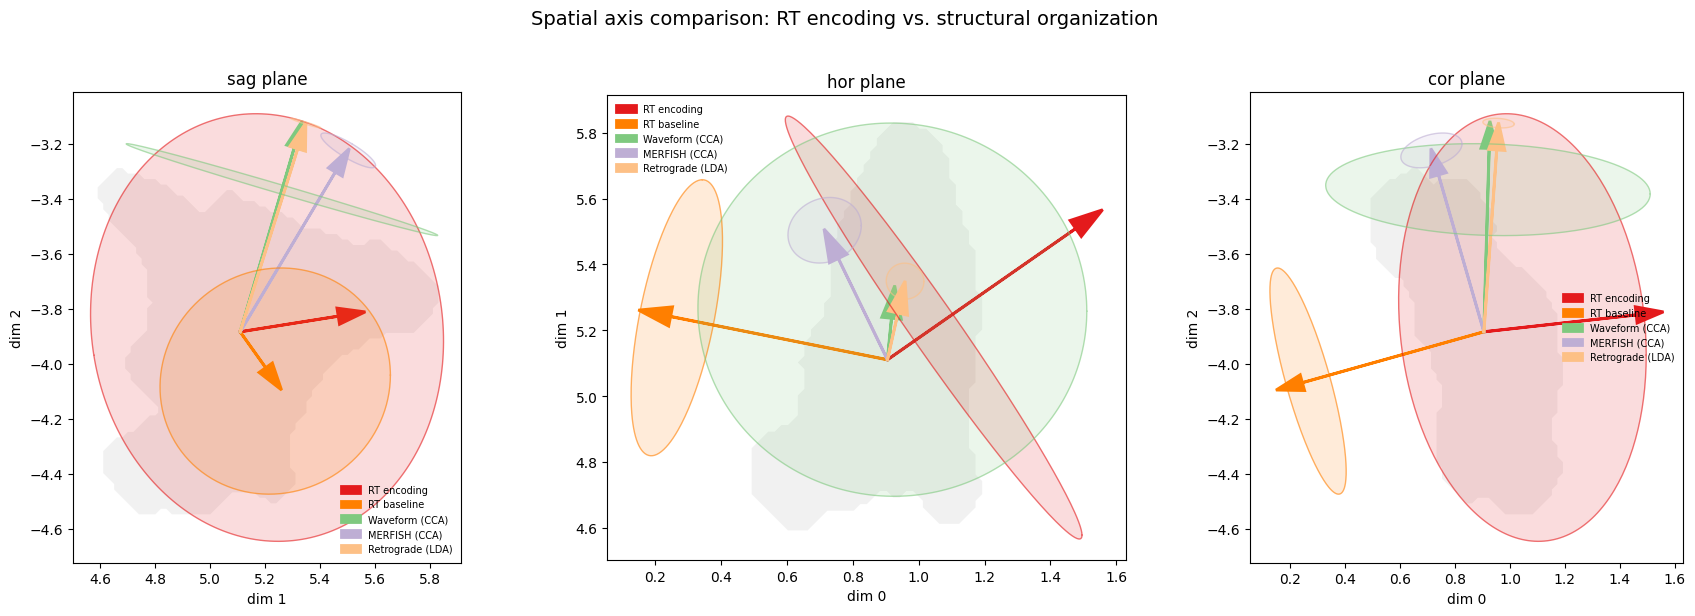

In [80]:
# Colors for each axis
COLORS = {
    "RT encoding": np.array([228, 26, 28]) / 255,    # red
    "RT baseline": np.array([255, 127, 0]) / 255,     # orange
    "Waveform (CCA)": np.array([127, 201, 127]) / 255,  # green (Han's x)
    "MERFISH (CCA)": np.array([190, 174, 212]) / 255,    # purple (Han's y)
    "Retrograde (LDA)": np.array([253, 192, 134]) / 255, # peach (Han's z)
}

fig, axes_arr = plt.subplots(1, 3, figsize=(18, 6))

for plane, ax in zip(PLANES.keys(), axes_arr):
    # Draw mesh background
    for c in mesh_contours[plane]:
        ax.fill(c[:, 0], c[:, 1], color="lightgray", alpha=0.3, linewidth=0)

    dims = PLANES[plane]
    origin = np.mean(mesh_vertices_mm[:, [dims[0], dims[1]]], axis=0)

    for name, (ax_vec, boot_vec) in axes_dict.items():
        color = COLORS.get(name, "gray")
        out = plot_projected_arrow_with_cone(
            ax, origin, ax_vec, boot_vec, dims,
            color=color, scale=0.8, head_width=0.06, head_length=0.10,
            cone_q=95, cone_alpha=0.15, label=name,
        )

    ax.set_title(f"{plane} plane", fontsize=12)
    ax.set_xlabel(f"dim {dims[0]}")
    ax.set_ylabel(f"dim {dims[1]}")
    ax.set_aspect("equal")
    ax.legend(fontsize=7, loc="best", frameon=False)

plt.suptitle("Spatial axis comparison: RT encoding vs. structural organization", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


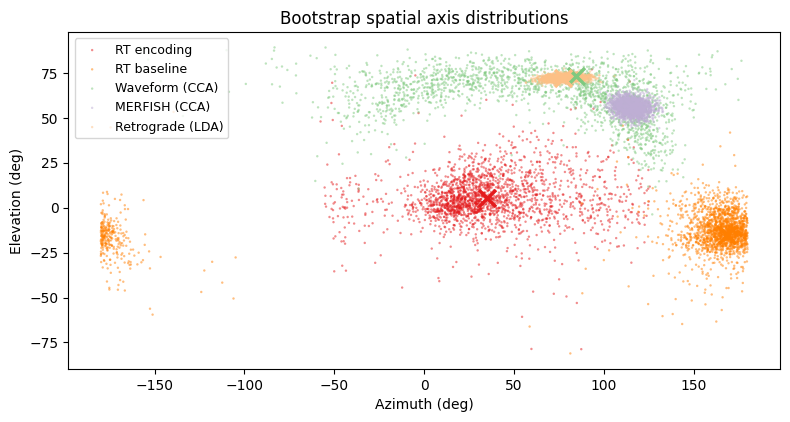

In [81]:
# Bootstrap distribution in azimuth-elevation space
fig, ax = plt.subplots(figsize=(8, 8))

for name, (ax_vec, boot_vec) in axes_dict.items():
    color = COLORS.get(name, "gray")
    az, el = vectors_to_az_el(boot_vec)
    ax.scatter(az, el, s=3, alpha=0.5, color=color, edgecolor="none", label=name)
    
    # Mark observed axis
    az_obs, el_obs = vectors_to_az_el(ax_vec.reshape(1, 3))
    ax.scatter(az_obs, el_obs, s=150, marker="x", color=color, linewidths=2.5, zorder=10)

ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Bootstrap spatial axis distributions")
ax.set_aspect("equal")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 10. Summary

### Interpretation guide

| Angle | p-value | Interpretation |
|-------|---------|----------------|
| Small (< 20°) | > 0.05 | Axes are **aligned** — RT encoding varies along the same spatial gradient as the structural feature |
| Large (> 45°) | < 0.05 | Axes are **different** — RT encoding has its own spatial organization |
| Intermediate | depends | Partial overlap; the axes share some but not all spatial structure |

If RT encoding aligns with the waveform/MERFISH/retrograde axis, it suggests that 
the same dorsoventral (or other) organizational axis that segregates LC cell types also 
organizes functional RT encoding — connecting your partial correlation finding to the 
structural organization of LC.


In [82]:
# Summary table
rows = []
for (name_a, name_b), res in comparison_results.items():
    rows.append({
        "Axis A": name_a,
        "Axis B": name_b,
        "Angle (°)": f"{res['angle_deg']:.1f}",
        "Wald W": f"{res['W_obs']:.2f}",
        "p (χ²)": f"{res['p_chi2']:.4g}",
        "p (boot)": f"{res['p_boot']:.4g}",
        "Aligned?": "yes" if res['p_boot'] > 0.05 else "no",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


        Axis A           Axis B Angle (°) Wald W    p (χ²)  p (boot) Aligned?
   RT encoding      RT baseline     133.6   2.87    0.2383    0.2444      yes
   RT encoding   Waveform (CCA)      74.3  13.43  0.001211  0.005997       no
   RT encoding    MERFISH (CCA)      80.7  14.13 0.0008552  0.005997       no
   RT encoding Retrograde (LDA)      71.9  17.26  0.000179  0.003498       no
   RT baseline   Waveform (CCA)     103.1  19.03 7.373e-05  0.003498       no
   RT baseline    MERFISH (CCA)      84.2  25.32 3.174e-06  0.002499       no
   RT baseline Retrograde (LDA)     105.0  25.14 3.473e-06  0.002499       no
Waveform (CCA)    MERFISH (CCA)      21.1   0.87    0.6485    0.6497      yes
Waveform (CCA) Retrograde (LDA)       2.5   0.08    0.9586     0.959      yes
 MERFISH (CCA) Retrograde (LDA)      22.2  29.24 4.483e-07 0.0004998       no


## 9b. Projection scatter: RT encoding onto structural axes

For each unit, project its 3D CCF coordinate onto the waveform / MERFISH / retrograde 
spatial axis to get a scalar "position along that gradient." Then correlate that 
position with the unit's RT encoding t-stat.

This answers: *Do units at different positions along the structural gradient 
(e.g. dorsal vs ventral LC, as defined by waveform type) differ in how 
strongly they encode RT?*

In [83]:
from scipy.stats import pearsonr, spearmanr

def get_regression_CI(x, y, n_pts=100, ci=0.95):
    """OLS fit line + pointwise confidence band."""
    from scipy import stats as sp_stats
    X = sm.add_constant(x)
    res = sm.OLS(y, X).fit()
    x_fit = np.linspace(x.min(), x.max(), n_pts)
    X_fit = sm.add_constant(x_fit)
    y_fit = res.predict(X_fit)
    
    # Prediction SE for mean response
    se = np.sqrt(np.sum((X_fit @ np.diag(np.sqrt(np.diag(res.cov_params())))) ** 2, axis=1))
    # More precise: use full covariance
    y_var = np.array([xi @ res.cov_params() @ xi for xi in X_fit])
    se = np.sqrt(y_var)
    
    t_crit = sp_stats.t.ppf((1 + ci) / 2, res.df_resid)
    return y_fit, x_fit, y_fit - t_crit * se, y_fit + t_crit * se


def plot_projection_scatter(
    coords, feature_values, feature_name,
    axes_dict_structural,
    colors_structural,
    *,
    center_coords_on_mesh=None,
    figsize_per_panel=(5, 5),
):
    """
    Project units onto each structural axis and scatter vs feature value.
    
    Parameters
    ----------
    coords : (n, 3) array, bregma-centered LPS mm
    feature_values : (n,) array, e.g. T_rt
    feature_name : str, for y-axis label and title
    axes_dict_structural : dict mapping name -> axis_unit (3-vector)
    colors_structural : dict mapping name -> color
    center_coords_on_mesh : (3,) array or None
        If provided, center coordinates on mesh centroid before projecting.
    """
    n_axes = len(axes_dict_structural)
    fig, axes_arr = plt.subplots(1, n_axes, figsize=(figsize_per_panel[0] * n_axes, figsize_per_panel[1]))
    if n_axes == 1:
        axes_arr = [axes_arr]
    
    valid_all = np.isfinite(feature_values) & np.all(np.isfinite(coords), axis=1)
    
    results = {}
    
    for ax, (axis_name, axis_vec) in zip(axes_arr, axes_dict_structural.items()):
        color = colors_structural.get(axis_name, "gray")
        
        # Project coordinates onto this axis
        c = coords.copy()
        if center_coords_on_mesh is not None:
            c = c - center_coords_on_mesh
        
        proj = c @ axis_vec  # scalar projection per unit
        
        valid = valid_all & np.isfinite(proj)
        proj_v = proj[valid]
        feat_v = feature_values[valid]
        
        # Scatter
        # Color points by feature value (diverging if signed)
        has_neg = np.any(feat_v < 0)
        if has_neg:
            amp = np.nanquantile(np.abs(feat_v), 0.95)
            if amp == 0:
                amp = 1.0
            norm = plt.Normalize(vmin=-amp, vmax=amp)
            cmap = "coolwarm"
        else:
            norm = None
            cmap = "viridis"
        
        sc = ax.scatter(
            proj_v, feat_v,
            c=feat_v, cmap=cmap, norm=norm,
            s=25, alpha=0.7, edgecolor="white", linewidth=0.3,
        )
        
        # Regression line + CI
        if len(proj_v) > 4:
            r, p = spearmanr(proj_v, feat_v)
            y_fit, x_fit, ci_lo, ci_hi = get_regression_CI(proj_v, feat_v)
            ax.plot(x_fit, y_fit, color="black", linewidth=1.5)
            ax.fill_between(x_fit, ci_lo, ci_hi, color="black", alpha=0.15)
            
            title_color = "red" if p < 0.05 else "black"
            ax.set_title(
                f"{feature_name} vs {axis_name}\n"
                f"r={r:.2f}, p={p:.3g}",
                color=title_color, fontsize=11,
            )
            results[axis_name] = {"r": r, "p": p, "n": len(proj_v)}
        else:
            ax.set_title(f"{feature_name} vs {axis_name}\nInsufficient data")
            results[axis_name] = {"r": np.nan, "p": np.nan, "n": len(proj_v)}
        
        ax.axhline(0, ls=":", color="gray", lw=0.5)
        ax.axvline(0, ls=":", color="gray", lw=0.5)
        
        ax.set_xlabel(f"Projection on {axis_name}", color=color, fontsize=10)
        ax.set_ylabel(feature_name)
        ax.tick_params(axis="x", colors=color)
    
    plt.tight_layout()
    return fig, results

In [84]:
# ---- Build structural axes dict (only those successfully loaded) ----
structural_axes = {}
structural_colors = {}

if HAS_WAVEFORM:
    structural_axes["wf_axis"] = axis_wf
    structural_colors["wf_axis"] = tuple(COLORS["Waveform (CCA)"])

if HAS_MERFISH:
    structural_axes["merfish_axis"] = axis_mer
    structural_colors["merfish_axis"] = tuple(COLORS["MERFISH (CCA)"])

if HAS_RETRO:
    structural_axes["retro_axis"] = axis_retro
    structural_colors["retro_axis"] = tuple(COLORS["Retrograde (LDA)"])

if not structural_axes:
    print("No structural axes loaded — skipping projection scatter.")
else:
    # Mesh centroid for centering (same as Han uses for arrow origin)
    mesh_centroid = np.mean(mesh_verts_lps_mm, axis=0)
    # Left-fold the ML component to match our coordinate convention
    mesh_centroid[ml] = -np.abs(mesh_centroid[ml])
    
    # Mesh centroid already computed with positive ML in the CCF setup cell
    print(f"Structural axes available: {list(structural_axes.keys())}")
    print(f"Mesh centroid (LPS mm): {mesh_centroid}")

Structural axes available: ['wf_axis', 'merfish_axis', 'retro_axis']
Mesh centroid (LPS mm): [-0.94130848  4.93866333 -3.97353415]


### RT response encoding (T_rt) projected onto structural axes

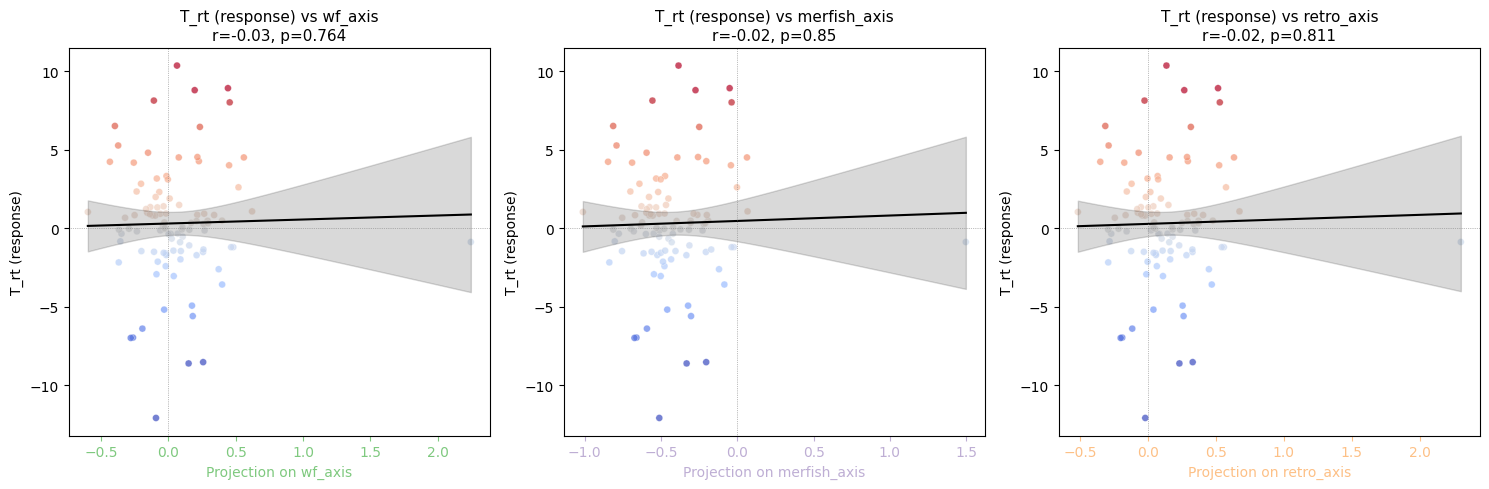


RT response encoding projected onto structural axes:
  wf_axis: r=-0.030, p=0.764, n=100  ns
  merfish_axis: r=-0.019, p=0.8496, n=100  ns
  retro_axis: r=-0.024, p=0.811, n=100  ns


In [85]:
if structural_axes:
    mask = (
        features_combined["T_rt"].notna()
        & features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)
    )
    fc_proj = features_combined.loc[mask]
    coords_proj = ccf_points_lps_mm(fc_proj, fold_left=True)
    feat_proj = fc_proj["T_rt"].to_numpy(dtype=float)

    fig_rt, results_rt = plot_projection_scatter(
        coords_proj, feat_proj, "T_rt (response)",
        structural_axes, structural_colors,
        center_coords_on_mesh=mesh_centroid,
    )
    plt.show()

    print("\nRT response encoding projected onto structural axes:")
    for name, res in results_rt.items():
        sig = "***" if res["p"] < 0.001 else "**" if res["p"] < 0.01 else "*" if res["p"] < 0.05 else "ns"
        print(f"  {name}: r={res['r']:.3f}, p={res['p']:.4g}, n={res['n']}  {sig}")

### RT baseline encoding (T_rt_bl) projected onto structural axes

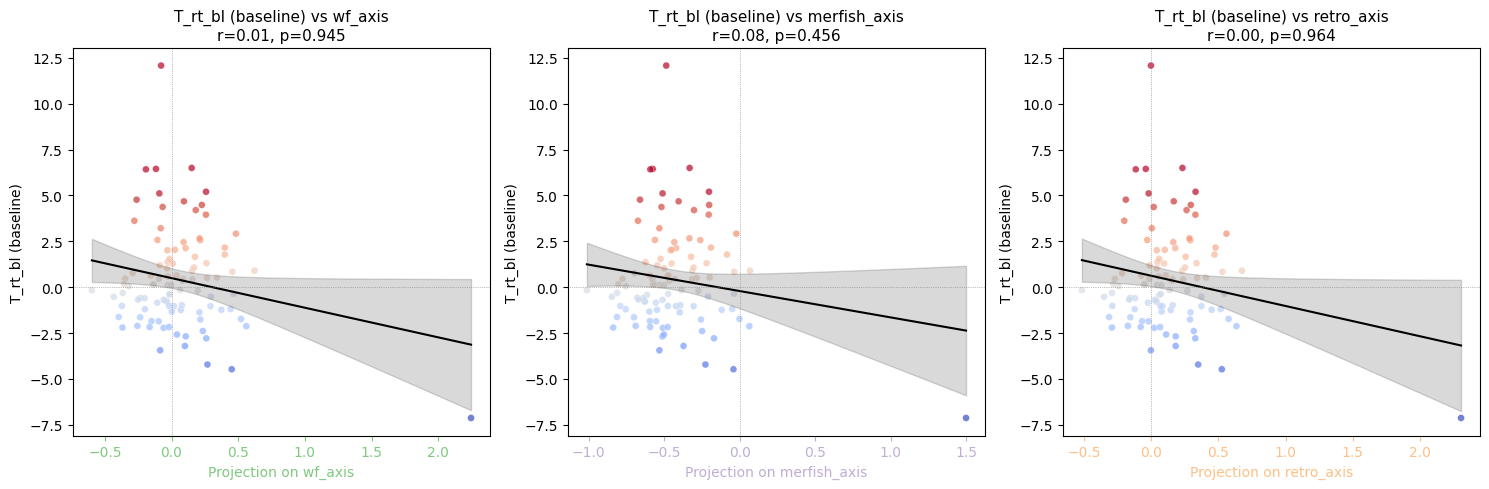


RT baseline encoding projected onto structural axes:
  wf_axis: r=0.007, p=0.9455, n=100  ns
  merfish_axis: r=0.075, p=0.4557, n=100  ns
  retro_axis: r=0.005, p=0.9641, n=100  ns


In [93]:
if structural_axes:
    mask_bl = (
        features_combined["T_rt_bl"].notna()
        & features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)
    )
    fc_proj_bl = features_combined.loc[mask_bl]
    coords_proj_bl = ccf_points_lps_mm(fc_proj_bl, fold_left=True)
    feat_proj_bl = fc_proj_bl["T_rt_bl"].to_numpy(dtype=float)

    fig_bl, results_bl = plot_projection_scatter(
        coords_proj_bl, feat_proj_bl, "T_rt_bl (baseline)",
        structural_axes, structural_colors,
        center_coords_on_mesh=mesh_centroid,
    )
    plt.show()

    print("\nRT baseline encoding projected onto structural axes:")
    for name, res in results_bl.items():
        sig = "***" if res["p"] < 0.001 else "**" if res["p"] < 0.01 else "*" if res["p"] < 0.05 else "ns"
        print(f"  {name}: r={res['r']:.3f}, p={res['p']:.4g}, n={res['n']}  {sig}")

### RT abs encoding (T_rt_bl) projected onto structural axes

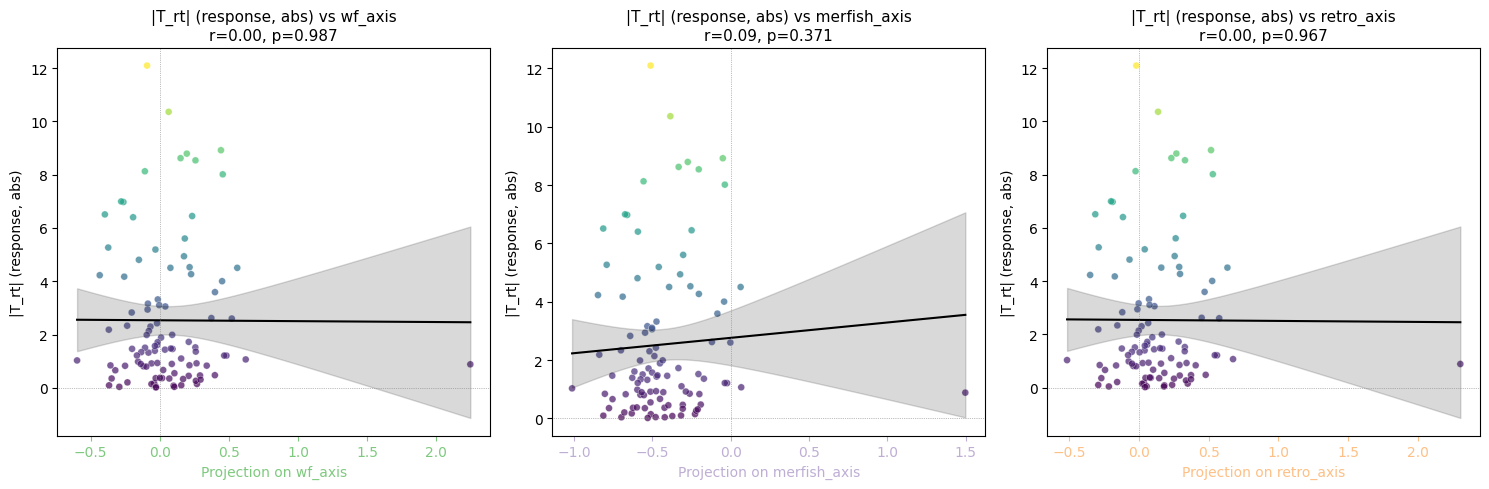


|RT response encoding| projected onto structural axes:
  wf_axis: r=0.002, p=0.9873, n=100  ns
  merfish_axis: r=0.090, p=0.3707, n=100  ns
  retro_axis: r=0.004, p=0.9675, n=100  ns


In [94]:
# ---- Absolute value of RT encoding projected onto structural axes ----
if structural_axes:
    mask = (
        features_combined["T_rt"].notna()
        & features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)
    )
    fc_proj = features_combined.loc[mask]
    coords_proj = ccf_points_lps_mm(fc_proj, fold_left=True)
    feat_proj_abs = np.abs(fc_proj["T_rt"].to_numpy(dtype=float))

    fig_rt_abs, results_rt_abs = plot_projection_scatter(
        coords_proj, feat_proj_abs, "|T_rt| (response, abs)",
        structural_axes, structural_colors,
        center_coords_on_mesh=mesh_centroid,
    )
    plt.show()

    print("\n|RT response encoding| projected onto structural axes:")
    for name, res in results_rt_abs.items():
        sig = "***" if res["p"] < 0.001 else "**" if res["p"] < 0.01 else "*" if res["p"] < 0.05 else "ns"
        print(f"  {name}: r={res['r']:.3f}, p={res['p']:.4g}, n={res['n']}  {sig}")

### Combined summary table

In [ ]:
if structural_axes:
    rows = []
    for feat_name, feat_results in [("T_rt (response)", results_rt), ("T_rt_bl (baseline)", results_bl)]:
        for axis_name, res in feat_results.items():
            rows.append({
                "Feature": feat_name,
                "Structural axis": axis_name,
                "Spearman r": f"{res['r']:.3f}",
                "p-value": f"{res['p']:.4g}",
                "n": res["n"],
                "sig": "yes" if res["p"] < 0.05 else "no",
            })
    
    proj_summary = pd.DataFrame(rows)
    print(proj_summary.to_string(index=False))
    print()
    print("Interpretation: a significant correlation means that units")
    print("at different positions along the structural gradient (e.g.")
    print("dorsal vs ventral LC as defined by waveform type) differ in")
    print("how strongly they encode RT.")

           Feature Structural axis Spearman r p-value   n sig
   T_rt (response)         wf_axis     -0.030   0.764 100  no
   T_rt (response)    merfish_axis     -0.019  0.8496 100  no
   T_rt (response)      retro_axis     -0.024   0.811 100  no
T_rt_bl (baseline)         wf_axis      0.007  0.9455 100  no
T_rt_bl (baseline)    merfish_axis      0.075  0.4557 100  no
T_rt_bl (baseline)      retro_axis      0.005  0.9641 100  no

Interpretation: a significant correlation means that units
at different positions along the structural gradient (e.g.
dorsal vs ventral LC as defined by waveform type) differ in
how strongly they encode RT.


In [88]:
def fit_rt_ols_per_unit(
    *,
    all_counts_df,
    get_session_prefix,
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    baseline_col="baseline_spike_count",
    unit_col_counts="unit_id",
    session_col_counts="session",
    min_trials=50,
    alpha=0.05,
    log_rt=True,
    zscore_rt=True,
):
    """
    Per-(session_prefix, unit) OLS regressions:
        count_col    ~ 1 + RT
        baseline_col ~ 1 + RT

    Returns a single DataFrame (rt_models) with columns:
        session_prefix, unit,
        n_trials, coef_rt, T_rt, p_rt, q_rt,
        n_trials_bl, coef_rt_bl, T_rt_bl, p_rt_bl, q_rt_bl
    """

    def canon_unit(x):
        try:
            return str(int(float(x)))
        except Exception:
            return str(x)

    def add_keys(df, session_col, unit_col):
        out = df.copy()
        out[session_col] = out[session_col].astype(str)
        out[unit_col] = out[unit_col].map(canon_unit)
        out["session_prefix"] = out[session_col].map(get_session_prefix).astype(str)
        out["unit"] = out[unit_col].astype(str)
        return out

    def _fit_per_key(counts, y_col, *, suffix):
        rows = []
        for (sp, u), g in counts.groupby(["session_prefix", "unit"]):
            g = g.dropna(subset=[rt_col, y_col])
            rt = g[rt_col].to_numpy(dtype=float)
            y = g[y_col].to_numpy(dtype=float)

            if log_rt:
                m = np.isfinite(rt) & (rt > 0) & np.isfinite(y)
            else:
                m = np.isfinite(rt) & np.isfinite(y)
            rt, y = rt[m], y[m]
            n = int(rt.size)

            if n < min_trials or np.nanstd(rt) == 0 or np.nanstd(y) == 0:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": n,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})
                continue

            x = np.log(rt) if log_rt else rt
            if zscore_rt:
                x = (x - np.nanmean(x)) / np.nanstd(x)

            X = sm.add_constant(x)
            try:
                res = sm.OLS(y, X).fit()
                rows.append({
                    "session_prefix": sp, "unit": u, "n_trials": n,
                    f"coef_{suffix}": float(res.params[1]),
                    f"T_{suffix}": float(res.tvalues[1]),
                    f"p_{suffix}": float(res.pvalues[1]),
                })
            except Exception:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": n,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})

        out = pd.DataFrame(rows).reset_index(drop=True)
        out[f"q_{suffix}"] = np.nan
        m = out[f"p_{suffix}"].notna()
        if m.any():
            _, q, _, _ = multipletests(out.loc[m, f"p_{suffix}"].values, alpha=alpha, method="fdr_bh")
            out.loc[m, f"q_{suffix}"] = q
        return out

    # --- Counts table ---
    counts = add_keys(all_counts_df, session_col_counts, unit_col_counts)

    # --- Fit two RT models ---
    rt_main = _fit_per_key(counts, count_col, suffix="rt")
    rt_base = _fit_per_key(counts, baseline_col, suffix="rt_bl")

    rt_models = rt_main.merge(rt_base, on=["session_prefix", "unit"], how="outer", validate="one_to_one")
    rt_models = rt_models.rename(columns={"n_trials_x": "n_trials", "n_trials_y": "n_trials_bl"})
    rt_models = rt_models[[
        "session_prefix", "unit",
        "n_trials", "coef_rt", "T_rt", "p_rt", "q_rt",
        "n_trials_bl", "coef_rt_bl", "T_rt_bl", "p_rt_bl", "q_rt_bl",
    ]]

    print(f"RT models: {len(rt_models)} units")
    print(f"  response window: {rt_models['T_rt'].notna().sum()} valid")
    print(f"  baseline window: {rt_models['T_rt_bl'].notna().sum()} valid")

    return rt_models
# Fit OLS regressions (independent of Sue)
rt_models = fit_rt_ols_per_unit(
    all_counts_df=all_counts_df,
    get_session_prefix=get_session_prefix,
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    baseline_col="baseline_spike_count",
    unit_col_counts="unit_id",
    session_col_counts="session",
    min_trials=50,
    alpha=0.05,
    log_rt=True,
    zscore_rt=True,
)
rt_models.head(10)

from per_unit_stats_registry import PerUnitStatsRegistry

SUE_FEATURES_PATH = "/root/capsule/scratch/features_combined_beh_all.pkl"
## 5. Register & compare
reg = PerUnitStatsRegistry(get_session_prefix=get_session_prefix, alpha=0.05)

# Register OLS RT models (response window + baseline window)
reg.register_regression(
    "ols_rt_response", rt_models,
    t_col="T_rt", p_col="p_rt", q_col="q_rt", coef_col="coef_rt", n_col="n_trials",
)
reg.register_regression(
    "ols_rt_baseline", rt_models,
    t_col="T_rt_bl", p_col="p_rt_bl", q_col="q_rt_bl", coef_col="coef_rt_bl", n_col="n_trials_bl",
)

# Load and register Sue's encoding table directly (no merge)
sue = pd.read_pickle(SUE_FEATURES_PATH)
n_sue = reg.register_sue(sue)
print(f"Registered {n_sue} Sue entries")

print()
print(reg)

RT models: 103 units
  response window: 103 valid
  baseline window: 103 valid
Registered 67 Sue entries

PerUnitStatsRegistry (69 entries):
  ols_rt_baseline                           n= 103  sig=  27  source=regression
  ols_rt_response                           n= 103  sig=  36  source=regression
  sue::Qchosen_com_mc                       n= 297  sig= 113  source=sue
  sue::Qchosen_com_ori                      n= 297  sig= 113  source=sue
  sue::Qchosen_e_mc                         n= 297  sig= 108  source=sue
  sue::Qchosen_e_ori                        n= 297  sig= 108  source=sue
  sue::Qchosen_indi_mc                      n= 297  sig= 108  source=sue
  sue::Qchosen_indi_ori                     n= 297  sig= 108  source=sue
  sue::Qchosen_l_mc                         n= 297  sig= 105  source=sue
  sue::Qchosen_l_ori                        n= 297  sig= 105  source=sue
  sue::amp_abs_com_mc                       n= 297  sig=  67  source=sue
  sue::amp_abs_com_ori                    

In [89]:
# ---- Map: Han's feature name -> registry name ----
sue_reg_map = {
    "T_baseline_svs_hit":  "sue::baseline_svs_hit",
    "T_response_svs_hit":  "sue::response_svs_hit",
    "T_outcome_com_mc":    "sue::outcome_com_mc",
    "T_outcome_l_mc":      "sue::outcome_l_mc",
    "T_baseline_hit_all":  "sue::baseline_hit_all",
    "T_response_hit_all":  "sue::response_hit_all",
}

# ---- Pull t-stats from registry and merge onto features_combined ----
for col_name, reg_name in sue_reg_map.items():
    if col_name in features_combined.columns:
        continue
    if reg_name not in reg:
        print(f"  {reg_name} not in registry, skipping")
        continue

    entry = reg.get(reg_name)  # has columns: session_prefix, unit, t, p, q, ...

    features_combined = features_combined.merge(
        entry[["session_prefix", "unit"]].assign(**{col_name: entry["t"]}),
        left_on=["session_prefix", "unit_str"],
        right_on=["session_prefix", "unit"],
        how="left",
        suffixes=("", f"__{reg_name}"),
    )
    # drop the extra 'unit' column from the merge
    drop_cols = [c for c in features_combined.columns if c.startswith("unit__")]
    features_combined.drop(columns=drop_cols, errors="ignore", inplace=True)

# Check
for col_name in sue_reg_map:
    n = features_combined[col_name].notna().sum() if col_name in features_combined.columns else 0
    print(f"  {col_name}: {n} units with data")

  T_baseline_svs_hit: 86 units with data
  T_response_svs_hit: 86 units with data
  T_outcome_com_mc: 86 units with data
  T_outcome_l_mc: 86 units with data
  T_baseline_hit_all: 73 units with data
  T_response_hit_all: 73 units with data


In [90]:
# ---- Pull Sue features from registry and merge onto features_combined ----

sue_feature_names = [
    "sue::T_baseline_svs_hit",
    "sue::T_response_svs_hit",
    "sue::T_outcome_com_mc",
    "sue::T_outcome_l_mc",
    "sue::T_baseline_hit_all",
    "sue::T_response_hit_all",
]

# Only use entries that actually exist in the registry
sue_feature_names = [n for n in sue_feature_names if n in reg]

# Ensure features_combined has the merge keys
if "session_prefix" not in features_combined.columns:
    features_combined["session_prefix"] = features_combined["session"].map(get_session_prefix)
if "unit_str" not in features_combined.columns:
    features_combined["unit_str"] = features_combined["unit"].map(
        lambda x: str(int(float(x))) if pd.notna(x) else str(x)
    )

for name in sue_feature_names:
    col_name = name.replace("sue::", "")  # e.g. "T_response_svs_hit"
    if col_name in features_combined.columns:
        continue  # already merged

    entry = reg.get(name)  # columns: session_prefix, unit, t, p, q, ...
    entry = entry.rename(columns={"t": col_name, "unit": "unit_reg"})

    features_combined = features_combined.merge(
        entry[["session_prefix", "unit_reg", col_name]],
        left_on=["session_prefix", "unit_str"],
        right_on=["session_prefix", "unit_reg"],
        how="left",
    ).drop(columns=["unit_reg"], errors="ignore")

print("Sue columns now in features_combined:")
for name in sue_feature_names:
    col = name.replace("sue::", "")
    n_valid = features_combined[col].notna().sum() if col in features_combined.columns else 0
    print(f"  {col}: {n_valid} units with data")

Sue columns now in features_combined:


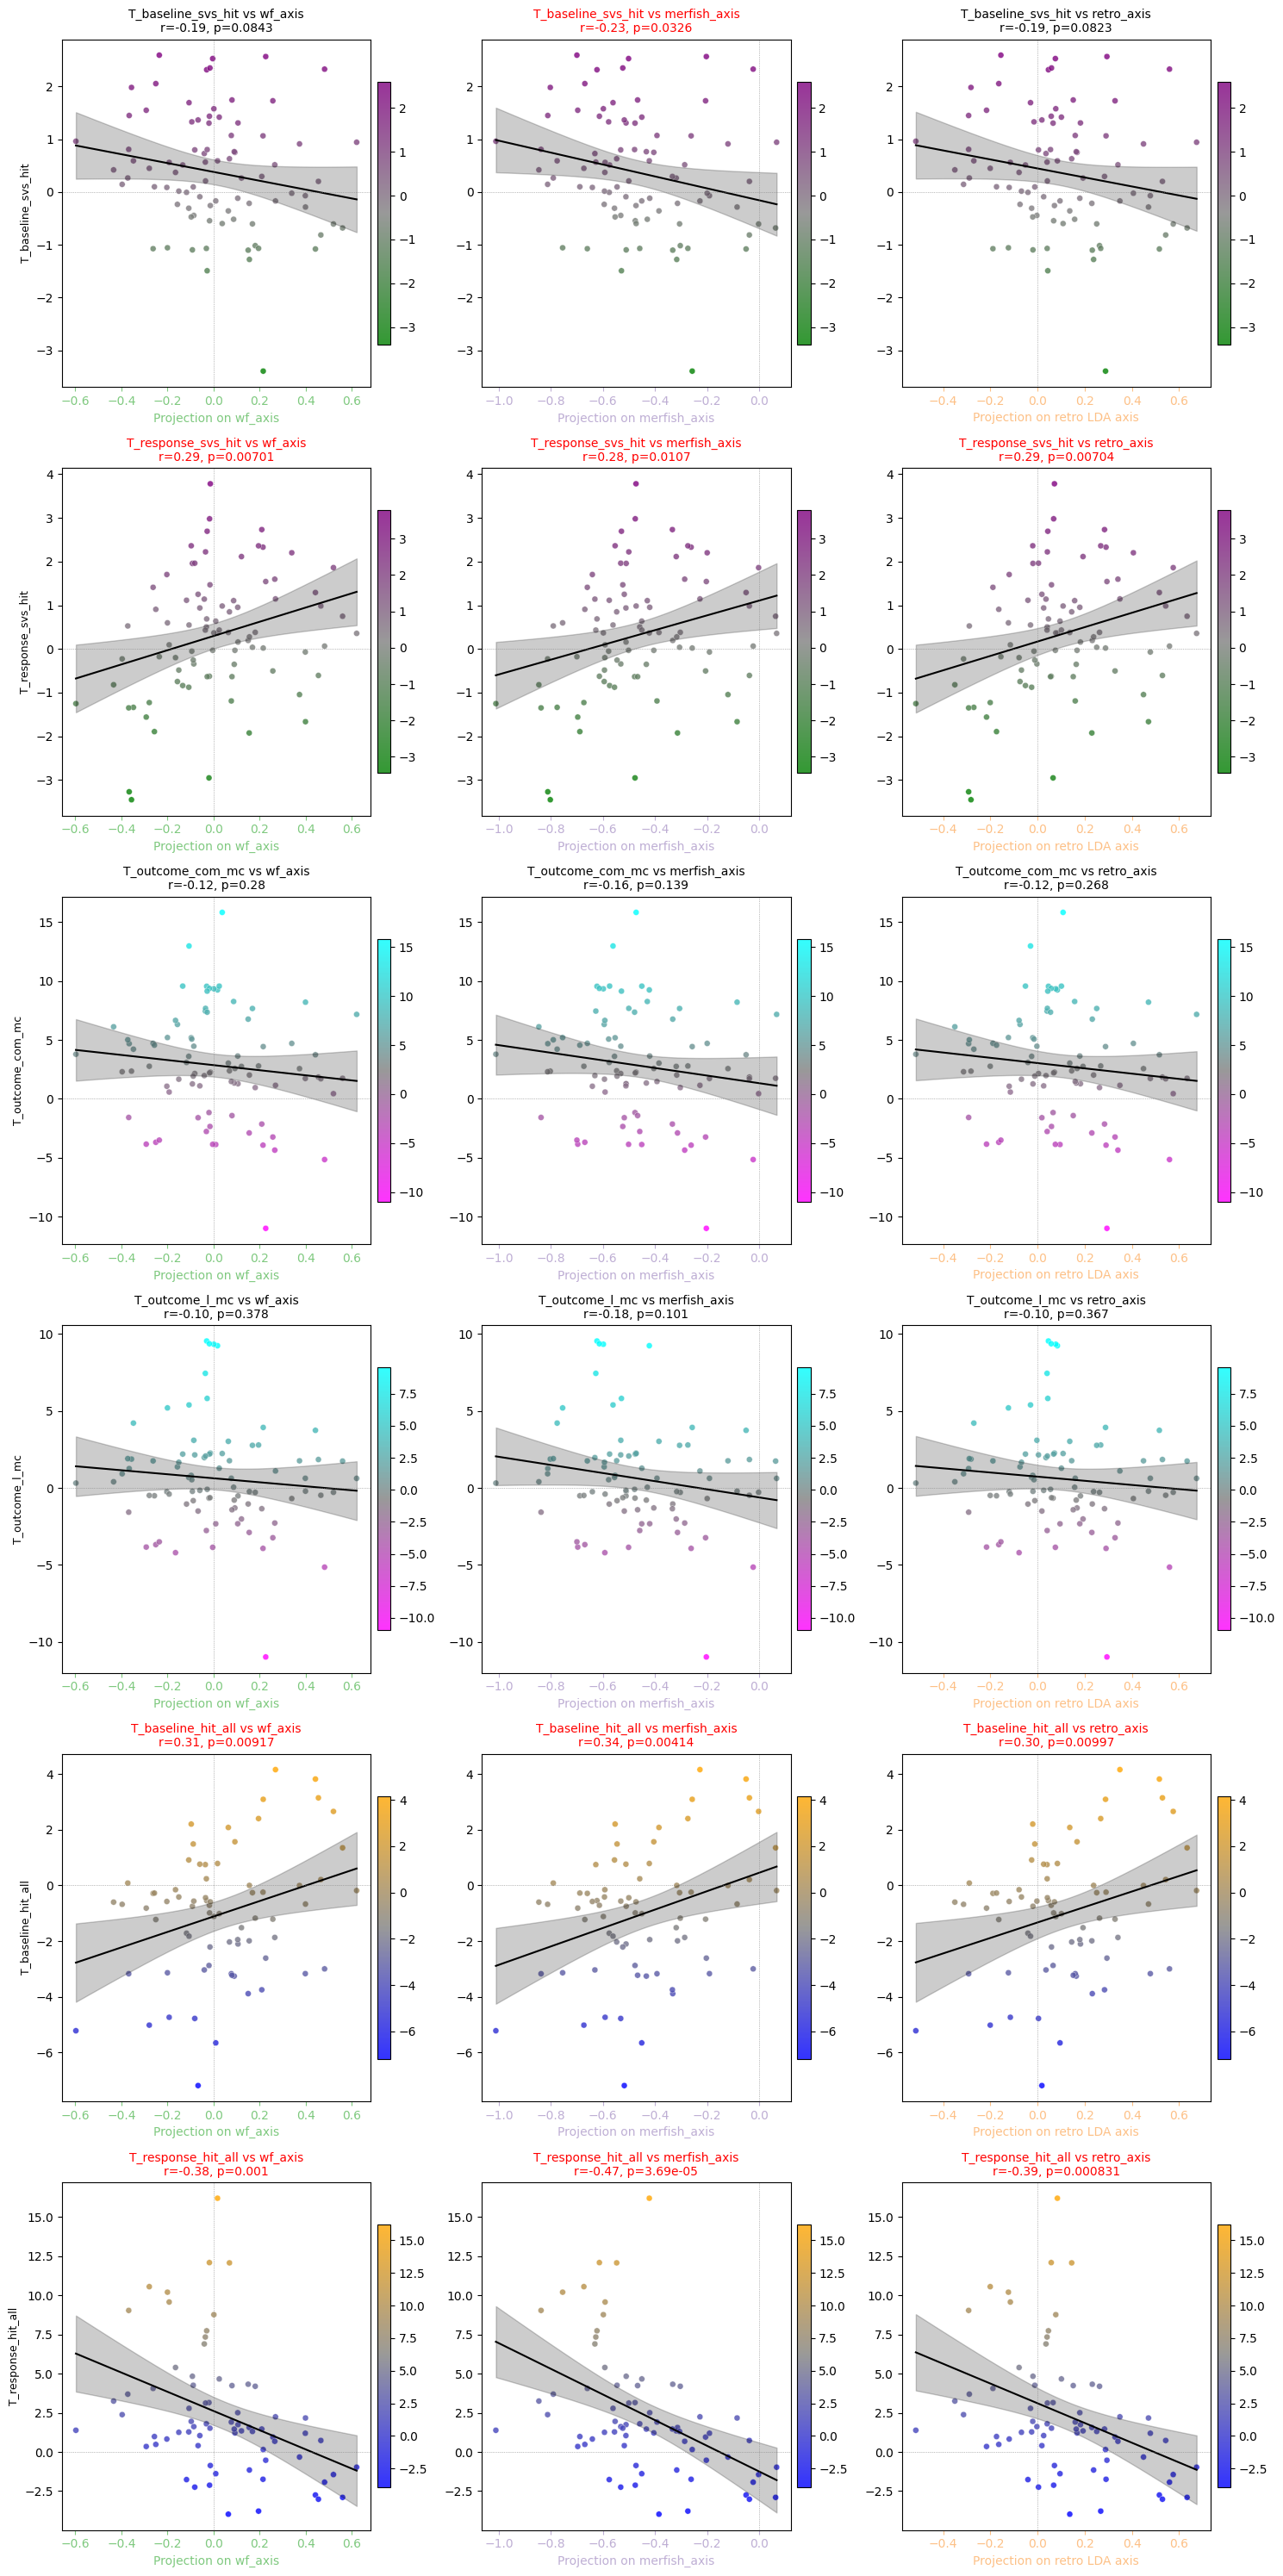

In [91]:
# ---- Sue feature map (matching Han's color conventions) ----
from matplotlib.colors import LinearSegmentedColormap

reward_colors = LinearSegmentedColormap.from_list('outcome', [(0.0, 'magenta'), (0.5, 'gray'), (1.0, 'cyan')])
hit_colors    = LinearSegmentedColormap.from_list('hit',     [(0.0, 'blue'),    (0.5, 'gray'), (1.0, 'orange')])
switch_colors = LinearSegmentedColormap.from_list('switch',  [(0.0, 'green'),   (0.5, 'gray'), (1.0, 'purple')])

sue_feature_map = {
    'T_baseline_svs_hit':  switch_colors,
    'T_response_svs_hit':  switch_colors,
    'T_outcome_com_mc':    reward_colors,
    'T_outcome_l_mc':      reward_colors,
    'T_baseline_hit_all':  hit_colors,
    'T_response_hit_all':  hit_colors,
}

# ---- Projection scatter: Sue features onto structural axes ----
from scipy.stats import pearsonr

if structural_axes:
    # Which Sue columns are actually present in features_combined?
    sue_cols_present = [c for c in sue_feature_map if c in features_combined.columns]
    if not sue_cols_present:
        print("No Sue columns found in features_combined. "
              "Merge sue_plus onto features_combined first.")
    else:
        axis_names = list(structural_axes.keys())
        axis_vecs  = [structural_axes[k] for k in axis_names]
        axis_colors_list = [structural_colors[k] for k in axis_names]
        axis_labels = {
            "wf_axis":     "Projection on wf_axis",
            "merfish_axis": "Projection on merfish_axis",
            "retro_axis":  "Projection on retro LDA axis",
        }

        # Coordinates: bregma-centered, left-folded, mesh-centered
        ccf_mask = features_combined[["x_ccf", "y_ccf", "z_ccf"]].notna().all(axis=1)
        ccfs_all = ccf_points_lps_mm(features_combined, fold_left=True)
        ccf_centered = ccfs_all - mesh_centroid

        fig, axes_arr = plt.subplots(
            len(sue_cols_present), len(axis_names),
            figsize=(5 * len(axis_names), 5 * len(sue_cols_present)),
            squeeze=False,
        )

        for i, feature in enumerate(sue_cols_present):
            feat_vals = features_combined[feature].to_numpy(dtype=float)
            cmap = sue_feature_map[feature]

            for j, (ax_name, ax_vec) in enumerate(zip(axis_names, axis_vecs)):
                ax = axes_arr[i, j]

                proj = ccf_centered @ ax_vec
                valid = np.isfinite(proj) & np.isfinite(feat_vals) & ccf_mask.values

                pv = proj[valid]
                fv = feat_vals[valid]

                sc = ax.scatter(pv, fv, c=fv, cmap=cmap, edgecolor='w',
                                linewidth=0.3, s=25, alpha=0.8)
                plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)

                if len(pv) > 4:
                    r, p = pearsonr(pv, fv)
                    y_fit, x_fit, ci_lo, ci_hi = get_regression_CI(pv, fv)
                    ax.plot(x_fit, y_fit, color='black', linewidth=1.5)
                    ax.fill_between(x_fit, ci_lo, ci_hi, color='black', alpha=0.2)

                    title_color = 'r' if p < 0.05 else 'black'
                    ax.set_title(f"{feature} vs {ax_name}\nr={r:.2f}, p={p:.3g}",
                                 color=title_color, fontsize=10)
                else:
                    ax.set_title(f"{feature} vs {ax_name}\nInsufficient data")

                ax.axhline(0, ls=':', color='gray', lw=0.5)
                ax.axvline(0, ls=':', color='gray', lw=0.5)

                ax.set_xlabel(axis_labels.get(ax_name, ax_name),
                              color=axis_colors_list[j])
                ax.tick_params(axis='x', colors=axis_colors_list[j])

                if j == 0:
                    ax.set_ylabel(feature, fontsize=9)

        plt.tight_layout()
        plt.show()

## 11. Optional: Register RT encoding in PerUnitStatsRegistry

If you want to use the `PerUnitStatsRegistry` to manage these stats 
alongside your Spearman correlations and Sue's encoding table:


In [92]:
# from per_unit_stats_registry import PerUnitStatsRegistry
# 
# reg = PerUnitStatsRegistry(get_session_prefix=get_session_prefix)
# 
# # Register the OLS RT encoding stats
# reg.register_regression(
#     "ols_rt_response",
#     rt_stats,
#     t_col="T_rt",
#     p_col="p_rt",
#     coef_col="coef_rt",
#     q_col="q_rt",
#     n_col="n_trials",
#     session_prefix_col="session_prefix",
#     unit_col="unit",
# )
# 
# reg.register_regression(
#     "ols_rt_baseline",
#     rt_stats,
#     t_col="T_rt_bl",
#     p_col="p_rt_bl",
#     coef_col="coef_rt_bl",
#     q_col="q_rt_bl",
#     n_col="n_trials",
#     session_prefix_col="session_prefix",
#     unit_col="unit",
# )
# 
# print(reg)
# reg.summary("ols_rt_response")
